In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('data/processed/listings_engineered.csv')
print(f'Loaded: {df.shape[0]:,} × {df.shape[1]}')

Loaded: 58,736 × 140


### Selecting Segmentation Features

In [3]:
# Features indicating price sensitivity and property characteristics
segmentation_features = [
    #price features
    'price',
    'price_per_person',
    'price_per_bedroom',
    'price_per_bed',
    'neighborhood_median_price',
    'price_vs_neighborhood',
    #property features
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'beds_per_bedroom',
    'bathrooms_per_bedroom',
    'capacity_per_bedroom',
    'property_type_encoded',
    'room_type_encoded',
    'is_entire_home',
    #review features
    'number_of_reviews',
    'number_of_reviews_ltm',          
    'number_of_reviews_l30d',         
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'avg_review_score',
    'has_reviews',
    'days_since_last_review',
    'has_recent_review',
    #host quality features
    'host_is_superhost',
    'host_quality_score',
    'is_professional_host',
    'host_listings_count',
    'host_total_listings_count',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'host_response_rate',
    'host_acceptance_rate',
    #availability & booking features
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'availability_rate',
    'is_highly_available',
    'booking_rate_proxy',
    'minimum_nights',
    'maximum_nights',
    'minimum_nights_avg_ntm',
    'is_flexible_booking',
    'instant_bookable_encoded',
    #location competitiveness
    'neighborhood_listing_count',
    'is_high_competition_area',
    #amenities
    'amenity_count',
    'essential_amenity_count',
    'has_pool',
    'has_hot_tub',
    'has_gym',
    #estimation features
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d'
]

# Keep only features that exist
segmentation_features = [f for f in segmentation_features if f in df.columns]

X_segment = df[segmentation_features]

print(f'Using {len(segmentation_features)} features for segmentation')
print(f'Listings: {X_segment.shape[0]:,}')

Using 61 features for segmentation
Listings: 58,736


### Standardize Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segment)

print('Features standardized (mean=0, std=1)')

Features standardized (mean=0, std=1)


### Determining Optimal Number of Clusters

k=2: Inertia=3309559, Silhouette=0.0881972281
k=3: Inertia=3105108, Silhouette=0.0945501314
k=4: Inertia=2945961, Silhouette=0.0826222131
k=5: Inertia=2823728, Silhouette=0.0718494782
k=6: Inertia=2727747, Silhouette=0.0755824336
k=7: Inertia=2649764, Silhouette=0.0733726670
k=8: Inertia=2575097, Silhouette=0.0786850821


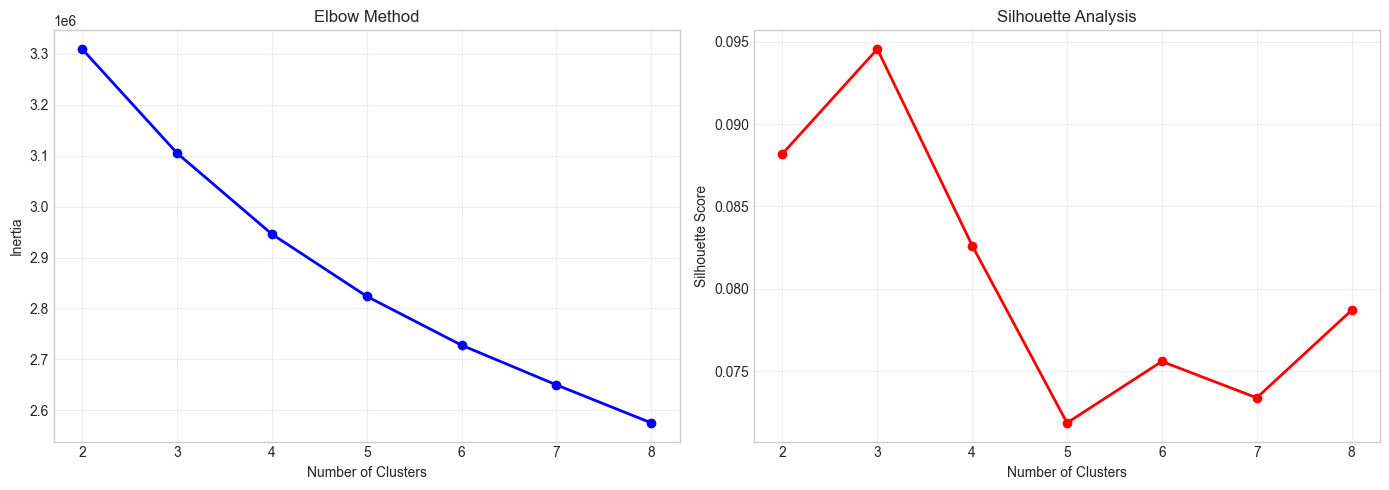

In [5]:
# Elbow method & Silhouette analysis
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f'k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={score:.10f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set(xlabel='Number of Clusters', ylabel='Inertia', title='Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set(xlabel='Number of Clusters', ylabel='Silhouette Score', title='Silhouette Analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Training K-Means with k=3

In [6]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=40, max_iter=300)
df['segment'] = kmeans.fit_predict(X_scaled)

print(f'K-Means clustering complete (k={optimal_k})')
print(f'\nSegment distribution:')
print(df['segment'].value_counts().sort_index())

K-Means clustering complete (k=3)

Segment distribution:
segment
0    17791
1     3979
2    36966
Name: count, dtype: int64


### Profiling Each Segment

In [7]:
# Calculating segment profiles
profile_features = ['price', 'accommodates', 'bedrooms', 'number_of_reviews',
                   'review_scores_rating', 'availability_rate', 'host_is_superhost',
                   'amenity_count', 'minimum_nights','beds','is_entire_home']
profile_features = [f for f in profile_features if f in df.columns]

segment_profiles = df.groupby('segment')[profile_features].agg(['median', 'mean']).round(2)

print(segment_profiles)

# Detailed breakdown
for seg in range(optimal_k):
    seg_data = df[df.segment == seg]
    print(f'\n--- Segment {seg} ---')
    print(f'Count: {len(seg_data):,} ({len(seg_data)/len(df)*100:.1f}%)')
    print(f'Median Price: ${seg_data.price.median():.0f}')
    if 'accommodates' in df.columns:
        print(f'Median Accommodates: {seg_data.accommodates.median():.0f}')
    if 'number_of_reviews' in df.columns:
        print(f'Median Reviews: {seg_data.number_of_reviews.median():.0f}')
    if 'host_is_superhost' in df.columns:
        print(f'Superhost %: {seg_data.host_is_superhost.mean()*100:.1f}%')

         price         accommodates       bedrooms       number_of_reviews  \
        median    mean       median  mean   median  mean            median   
segment                                                                      
0         60.0   72.65          2.0  1.87      1.0  1.05              10.0   
1        122.0  153.08          3.0  3.71      1.0  1.48               4.0   
2        175.0  229.85          4.0  4.27      2.0  1.77               8.0   

               review_scores_rating        ... host_is_superhost        \
          mean               median  mean  ...            median  mean   
segment                                    ...                           
0        41.20                 4.86  4.81  ...               0.0  0.27   
1         6.85                 4.00  3.72  ...               0.0  0.04   
2        23.68                 4.80  4.79  ...               0.0  0.25   

        amenity_count        minimum_nights         beds       is_entire_home  \
     

### Visualizing Segments

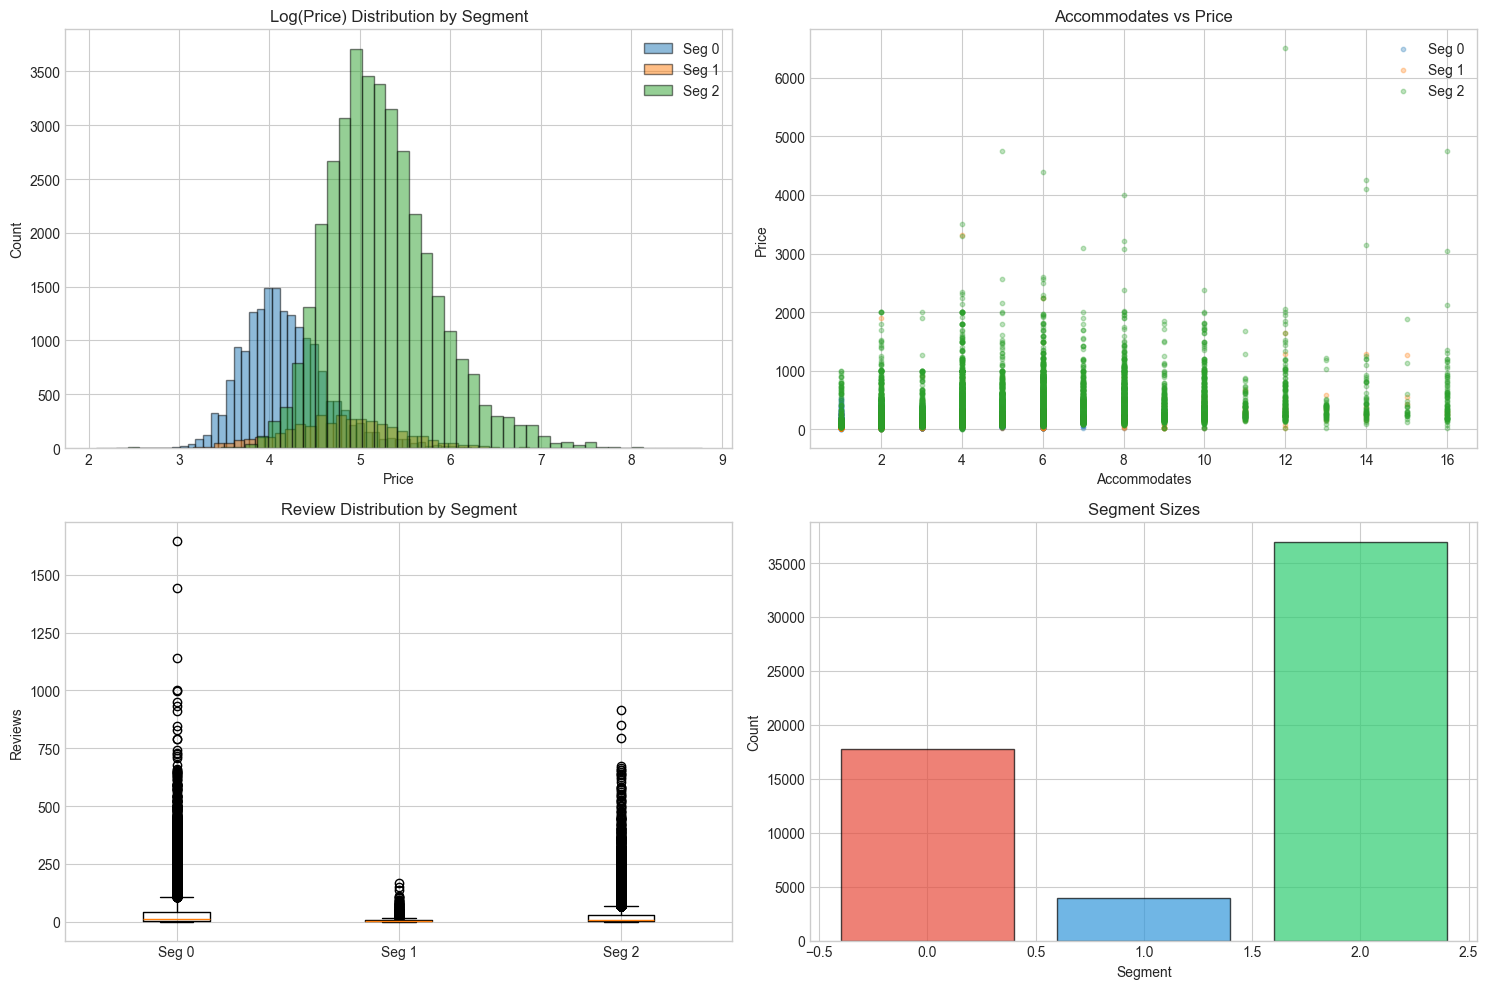

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price distribution by segment
for seg in range(optimal_k):
    segment_data = np.log1p(df[df.segment == seg]['price'])
    axes[0, 0].hist(segment_data, bins=50, alpha=0.5, label=f'Seg {seg}', edgecolor='black')
axes[0, 0].set(xlabel='Price', ylabel='Count', title='Log(Price) Distribution by Segment')
axes[0, 0].legend()

# Accommodates vs Price
if 'accommodates' in df.columns:
    for seg in range(optimal_k):
        segment_data = df[df.segment == seg]
        axes[0, 1].scatter(segment_data['accommodates'], segment_data['price'],
                          alpha=0.3, label=f'Seg {seg}', s=10)
    axes[0, 1].set(xlabel='Accommodates', ylabel='Price', title='Accommodates vs Price')
    axes[0, 1].legend()

# Reviews distribution
if 'number_of_reviews' in df.columns:
    segment_reviews = [df[df.segment == seg]['number_of_reviews'] for seg in range(optimal_k)]
    axes[1, 0].boxplot(segment_reviews, labels=[f'Seg {i}' for i in range(optimal_k)])
    axes[1, 0].set(ylabel='Reviews', title='Review Distribution by Segment')

# Segment sizes
segment_sizes = df['segment'].value_counts().sort_index()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
axes[1, 1].bar(range(optimal_k), segment_sizes.values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set(xlabel='Segment', ylabel='Count', title='Segment Sizes')

plt.tight_layout()
plt.show()

### Labeling Segments for Interpretation

In [10]:
# Manual labeling based on characteristics

# Analyzing to determine labels
median_prices = df.groupby('segment')['price'].median().sort_values()
print('Segments by median price (low to high):')
print(median_prices)

# Example labeling (adjust based on your data)
segment_labels = {
    median_prices.index[0]: 'Budget Travelers',
    median_prices.index[1]: 'Mid-Range/Niche', 
    median_prices.index[2]: 'Mainstream'
}

df['segment_name'] = df['segment'].map(segment_labels)

print('\nSegment level Interpretation:')
for seg, name in segment_labels.items():
    seg_data = df[df.segment == seg]
    print(f'\nSegment {seg}: {name}')
    print(f'  Count: {len(seg_data):,} ({len(seg_data)/len(df)*100:.1f}%)')
    print(f'  Median Price: ${seg_data.price.median():.0f}')
    if 'accommodates' in df.columns:
        print(f'  Avg Accommodates: {seg_data.accommodates.mean():.1f}')
    if 'amenity_count' in df.columns:
        print(f'  Avg Amenities: {seg_data.amenity_count.mean():.1f}')

Segments by median price (low to high):
segment
0     60.0
1    122.0
2    175.0
Name: price, dtype: float64

Segment level Interpretation:

Segment 0: Budget Travelers
  Count: 17,791 (30.3%)
  Median Price: $60
  Avg Accommodates: 1.9
  Avg Amenities: 26.2

Segment 1: Mid-Range/Niche
  Count: 3,979 (6.8%)
  Median Price: $122
  Avg Accommodates: 3.7
  Avg Amenities: 27.6

Segment 2: Mainstream
  Count: 36,966 (62.9%)
  Median Price: $175
  Avg Accommodates: 4.3
  Avg Amenities: 34.4


### Estimating Price Elasticity by Segment

In [11]:
from sklearn.linear_model import HuberRegressor

print('\nUsing Huber Regression, which is robust to within segment outliers that might skew results.')
print('This approach automatically downweights extreme values')
print('without requiring manual outlier removal.')

elasticities = {}

for seg, name in segment_labels.items():
    segment_data = df[df.segment == seg].copy()
    
    valid = (segment_data['price'] > 0) & (segment_data['reviews_per_month'] > 0)
    segment_data = segment_data[valid]
    
    if len(segment_data) < 100:
        continue
    
    segment_data['log_price'] = np.log(segment_data['price'])
    segment_data['log_demand'] = np.log(segment_data['reviews_per_month'])
    
    X = segment_data[['log_price']].values
    y = segment_data['log_demand'].values
    
    reg = HuberRegressor(epsilon=1.35, max_iter=200)
    reg.fit(X, y)
    
    elasticity = reg.coef_[0]
    elasticities[seg] = elasticity
    
    print(f'\n{name}:')
    print(f'  Robust Elasticity: {elasticity:.3f}')


Using Huber Regression, which is robust to within segment outliers that might skew results.
This approach automatically downweights extreme values
without requiring manual outlier removal.

Budget Travelers:
  Robust Elasticity: -0.127

Mid-Range/Niche:
  Robust Elasticity: -0.139

Mainstream:
  Robust Elasticity: -0.160


### Validating with Cross Price Elasticity

In [13]:
# Adding neighborhood median price as a feature
from sklearn.linear_model import HuberRegressor

for seg, name in segment_labels.items():
    segment_data = df[df.segment == seg].copy()
    
    # Require neighborhood data
    if 'neighborhood_median_price' not in df.columns:
        continue
    
    valid = (
        (segment_data['price'] > 0) & 
        (segment_data['reviews_per_month'] > 0) &
        (segment_data['neighborhood_median_price'] > 0)
    )
    segment_data = segment_data[valid]
    
    if len(segment_data) < 100:
        continue
    
    # Log transformation
    segment_data['log_price'] = np.log(segment_data['price'])
    segment_data['log_neighborhood_price'] = np.log(segment_data['neighborhood_median_price'])
    segment_data['log_demand'] = np.log(segment_data['reviews_per_month'])
    
    # Multivariate model: demand ~ own_price + competitor_price
    X = segment_data[['log_price', 'log_neighborhood_price']].values
    y = segment_data['log_demand'].values
    
    reg = HuberRegressor()
    reg.fit(X, y)
    
    own_price_elasticity = reg.coef_[0]
    cross_price_elasticity = reg.coef_[1]
    
    print(f'\n{name}:')
    print(f'Own-price elasticity: {own_price_elasticity:.3f}')
    print(f'Cross-price elasticity: {cross_price_elasticity:.3f}')
    
    if cross_price_elasticity > 0:
        print(f'When neighborhood prices rise, demand increases. So guests are sensitive to relative pricing.')
    else:
        print(f'When neighborhood prices rise, demand decreases. Guests dont care about relative pricing.')


Budget Travelers:
Own-price elasticity: -0.240
Cross-price elasticity: 0.580
When neighborhood prices rise, demand increases. So guests are sensitive to relative pricing.

Mid-Range/Niche:
Own-price elasticity: -0.228
Cross-price elasticity: 0.504
When neighborhood prices rise, demand increases. So guests are sensitive to relative pricing.

Mainstream:
Own-price elasticity: -0.216
Cross-price elasticity: 0.281
When neighborhood prices rise, demand increases. So guests are sensitive to relative pricing.


### Saving Segmented Data

In [14]:
# Save with segments
df.to_csv('data/processed/listings_segmented.csv', index=False)
print('Saved: listings_segmented.csv')

# Save segment info
segment_info = pd.DataFrame({
    'segment': list(segment_labels.keys()),
    'name': list(segment_labels.values()),
    'count': [len(df[df.segment == seg]) for seg in segment_labels.keys()],
    'median_price': [df[df.segment == seg].price.median() for seg in segment_labels.keys()],
    'elasticity': [elasticities.get(seg, np.nan) for seg in segment_labels.keys()]
})

segment_info.to_csv('outputs/segment_profiles.csv', index=False)
print('Saved: segment_profiles.csv')

Saved: listings_segmented.csv
Saved: segment_profiles.csv


### Summary

In [15]:
print(f'Clusters: {optimal_k}')
print(f'Features used: {len(segmentation_features)}')
print(f'\nSegments created:')
for seg, name in segment_labels.items():
    pct = len(df[df.segment == seg])/len(df)*100
    price = df[df.segment == seg].price.median()
    elast = elasticities.get(seg, 0)
    print(f'  {seg}. {name}: {pct:.1f}%, ${price:.0f} median, elasticity={elast:.2f}')
print(f'\nNext: Demand modeling per segment')

Clusters: 3
Features used: 61

Segments created:
  0. Budget Travelers: 30.3%, $60 median, elasticity=-0.13
  1. Mid-Range/Niche: 6.8%, $122 median, elasticity=-0.14
  2. Mainstream: 62.9%, $175 median, elasticity=-0.16

Next: Demand modeling per segment
